# Activity: Run simple linear regression

## **Introduction**


As you're learning, simple linear regression is a way to model the relationship between two variables. By assessing the direction and magnitude of a relationship, data professionals are able to uncover patterns and transform large amounts of data into valuable knowledge. This enables them to make better predictions and decisions. 

In this lab, you are part of an analytics team that provides insights about your company's sales and marketing practices. You have been assigned to a project that focuses on the use of influencer marketing. For this task, you will explore the relationship between your radio promotion budget and your sales. 

The dataset provided includes information about marketing campaigns across TV, radio, and social media, as well as how much revenue in sales was generated from these campaigns. Based on this information, company leaders will make decisions about where to focus future marketing resources. Therefore, it is critical to provide them with a clear understanding of the relationship between types of marketing campaigns and the revenue generated as a result of this investment.

## **Step 1: Imports** 


Import relevant Python libraries and modules.

In [1]:
# Import relevant Python libraries and modules.

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm


The dataset provided is a .csv file (named `marketing_sales_data.csv`), which contains information about marketing conducted in collaboration with influencers, along with corresponding sales. Assume that the numerical variables in the data are expressed in millions of dollars. As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

**Note:** This is a fictional dataset that was created for educational purposes and modified for this lab. 

In [2]:
# RUN THIS CELL TO IMPORT YOUR DATA.

data = pd.read_csv("marketing_sales_data.csv")

## **Step 2: Data exploration** 


To get a sense of what the data includes, display the first 10 rows of the data.

In [3]:
# Display the first 10 rows of the data.

data.head(10)


,TV,Radio,Social Media,Influencer,Sales
0,Low,1.218354,1.270444,Micro,90.054222
1,Medium,14.949791,0.274451,Macro,222.741668
2,Low,10.377258,0.061984,Mega,102.774790
3,High,26.469274,7.070945,Micro,328.239378
4,High,36.876302,7.618605,Mega,351.807328
5,High,25.561910,5.459718,Micro,261.966812
6,High,37.263819,6.886535,Nano,349.861575
7,Low,13.187256,2.766352,Macro,140.415286
8,High,29.520170,2.333157,Nano,264.592233
9,Low,3.773287,0.135074,Nano,55.674214


**Question:** What do you observe about the different variables included in the data?

The dataset consists of both categorical and numerical variables. Specifically, the variables TV, Radio, and Social Media represent numerical marketing expenditures, while Influencer is a categorical variable indicating the type of influencer used. The Sales variable is numerical and represents the revenue generated. This combination of variables allows for analysis of how different marketing channels relate to sales outcomes.

Next, to get a sense of the size of the dataset, identify the number of rows and the number of columns.

In [4]:
# Display number of rows, number of columns.

data.shape


(572, 5)

**Question:** How many rows and columns exist in the data?

The dataset contains 572 rows and 5 columns.

Now, check for missing values in the rows of the data. This is important because missing values are not that meaningful when modeling the relationship between two variables. To do so, begin by getting Booleans that indicate whether each value in the data is missing. Then, check both columns and rows for missing values.

In [5]:
# Start with .isna() to get booleans indicating whether each value in the data is missing.

data.isna()


,TV,Radio,Social Media,Influencer,Sales
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
567,False,False,False,False,False
568,False,False,False,False,False
569,False,False,False,False,False
570,False,False,False,False,False


If you would like to read more about the `isna()` function, refer to its documentation in the references section of this lab.

In [6]:
# Use .any(axis=1) to get booleans indicating whether there are any missing values along the columns in each row.

data.isna().any(axis=1)


0      False
1      False
2      False
3      False
4      False
       ...  
567    False
568    False
569    False
570    False
571    False
Length: 572, dtype: bool

If you would like to read more about the `any()` function, refer to its documentation in the references section of this lab.

In [7]:
# Use .sum() to get the number of rows that contain missing values.

data.isna().any(axis=1).sum()


3

If you would like to read more about the `sum()` function, refer to its documentation in the references section of this lab.

**Question:** How many rows containing missing values?

There are 3 rows containing missing values in the dataset.

Next, drop the rows that contain missing values. Data cleaning makes your data more usable for analysis and regression. Then, check to make sure that the resulting data does not contain any rows with missing values.

In [8]:
# Use .dropna(axis=0) to indicate that you want rows which contain missing values to be dropped. To update the DataFrame, reassign it to the result.

data = data.dropna()


In [9]:
# Start with .isna() to get booleans indicating whether each value in the data is missing.
# Use .any(axis=1) to get booleans indicating whether there are any missing values along the columns in each row.
# Use .sum() to get the number of rows that contain missing values

data.isna().any(axis=1).sum()


0

The next step for this task is checking model assumptions. To explore the relationship between radio promotion budget and sales, model the relationship using linear regression. Begin by confirming whether the model assumptions for linear regression can be made in this context. 

**Note:** Some of the assumptions can be addressed before the model is built. These will be addressed in this section. After the model is built, you will finish checking the assumptions.

Create a plot of pairwise relationships in the data. This will help you visualize the relationships and check model assumptions. 

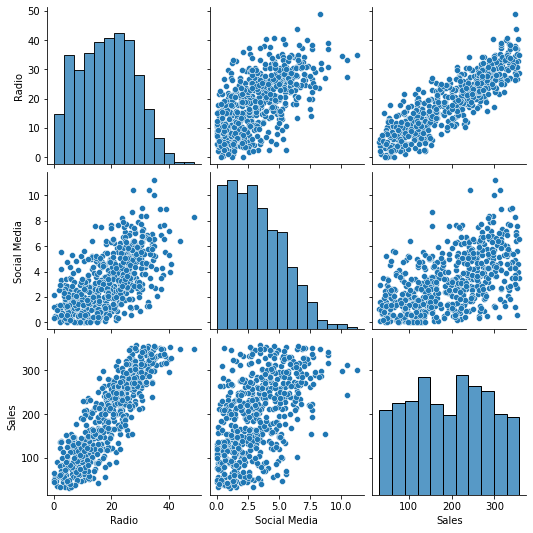

In [10]:
# Create plot of pairwise relationships.

sns.pairplot(data)
plt.show()


**Question:** Is the assumption of linearity met?

Yes, the assumption of linearity is met. The scatterplot of Sales versus Radio (visible in the pairplot on page 6) shows a clear positive linear trend, indicating that a linear model is appropriate for this relationship.

## **Step 3: Model building** 

Select only the columns that are needed for the model.

In [13]:
# Select relevant columns.
# Save resulting DataFrame in a separate variable to prepare for regression.

df = data[['Radio', 'Sales']]


Now, display the first 10 rows of the new DataFrame to better understand the data.

In [14]:
# Display first 10 rows of the new DataFrame.

df.head(10)


,Radio,Sales
0,1.218354,90.054222
1,14.949791,222.741668
2,10.377258,102.774790
3,26.469274,328.239378
4,36.876302,351.807328
5,25.561910,261.966812
6,37.263819,349.861575
7,13.187256,140.415286
8,29.520170,264.592233
9,3.773287,55.674214


Next, write the linear regression formula for modeling the relationship between the two variables of interest.

In [15]:
# Write the linear regression formula.
# Save it in a variable.

formula = "Sales ~ Radio"


Now, implement the ordinary least squares (OLS) approach for linear regression.

In [16]:
# Implement OLS.

model = smf.ols(formula=formula, data=df).fit()


Now, create a linear regression model for the data and fit the model to the data.

In [18]:
# Fit the model to the data.
# Save the fitted model in a variable.

fitted_model = model

## **Step 4: Results and evaluation** 


Begin by getting a summary of the results from the model.

In [19]:
# Get summary of results.

fitted_model.summary()



<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.757
Model:                            OLS   Adj. R-squared:                  0.757
Method:                 Least Squares   F-statistic:                     1768.
Date:                Sun, 26 Apr 2026   Prob (F-statistic):          2.07e-176
Time:                        17:08:09   Log-Likelihood:                -2966.7
No. Observations:                 569   AIC:                             5937.
Df Residuals:                     567   BIC:                             5946.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     41.5326      4.067     10.211      0.000      33.544      49.521
Radio          8.1733      0.194     42.048      0.000       7.791       8.555
==============================================================================
Omnibus:                        2.267   Durbin-Watson:                   1.880
Prob(Omnibus):                  0.322   Jarque-Bera (JB):                2.221
Skew:                          -0.102   Prob(JB):                        0.329
Kurtosis:                       2.772   Cond. No.                         45.7
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Next, analyze the bottom table from the results summary. Based on the table, identify the coefficients that the model determined would generate the line of best fit. The coefficients are the y-intercept and the slope. 

**Question:** What is the y-intercept? 

The y-intercept is approximately 41.53.

**Question:** What is the slope? 

The slope is approximately 8.17.

**Question:** What linear equation would you write to express the relationship between sales and radio promotion budget? Use the form of y = slope * x + y-intercept? 


Sales=8.17×Radio+41.53

**Question:** What does the slope mean in this context?

The slope indicates that for every one-unit increase in the radio promotion budget (in millions of dollars), sales are expected to increase by approximately 8.17 million dollars, assuming all other factors remain constant.

Now that you've built the linear regression model and fit it to the data, finish checking the model assumptions. This will help confirm your findings. First, plot the OLS data with the best fit regression line.

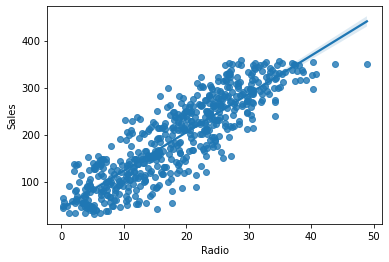

In [20]:
# Plot the OLS data with the best fit regression line.

sns.regplot(x='Radio', y='Sales', data=df)
plt.show()


**Question:** What do you observe from the preceding regression plot?

The regression plot shows a strong positive linear relationship between radio advertising expenditure and sales. The data points are closely clustered around the regression line, indicating a good fit and suggesting that radio advertising is a strong predictor of sales.

Now, check the normality assumption. Get the residuals from the model.

In [22]:
# Get the residuals from the model.

residuals = fitted_model.resid
residuals

0      38.563673
1      59.020221
2     -23.574057
3      70.365959
4       8.874344
         ...    
567    30.781101
568    -1.692607
569   -42.591308
570   -14.093977
571   -12.799642
Length: 569, dtype: float64

Now, visualize the distribution of the residuals.

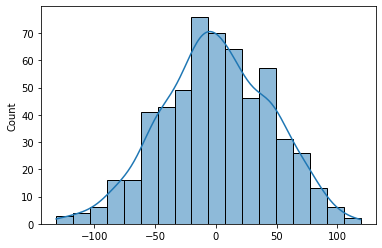

In [23]:
# Visualize the distribution of the residuals.

sns.histplot(residuals, kde=True)
plt.show()


**Question:** Based on the visualization, what do you observe about the distribution of the residuals?

The residuals appear to be approximately normally distributed, as indicated by the histogram (page 12), which shows a roughly symmetric bell-shaped distribution centered around zero.

Next, create a Q-Q plot to confirm the assumption of normality.

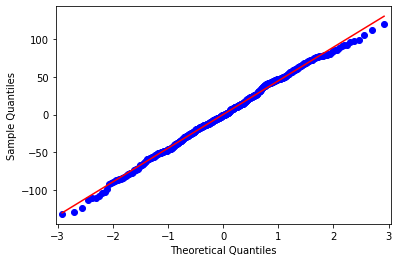

In [24]:
# Create a Q-Q plot.

sm.qqplot(residuals, line='s')
plt.show()


**Question:** Is the assumption of normality met?

Yes, the assumption of normality is met. The Q-Q plot (page 13) shows that the residuals closely follow the reference line, indicating that they are approximately normally distributed.

Now, check the assumptions of independent observation and homoscedasticity. Start by getting the fitted values from the model.

In [26]:
# Get fitted values.

fitted_values = fitted_model.fittedvalues
fitted_values

0       51.490549
1      163.721447
2      126.348847
3      257.873419
4      342.932984
          ...    
567    272.106897
568    234.247630
569    116.480147
570    136.043547
571    195.311256
Length: 569, dtype: float64

Next, create a scatterplot of the residuals against the fitted values.

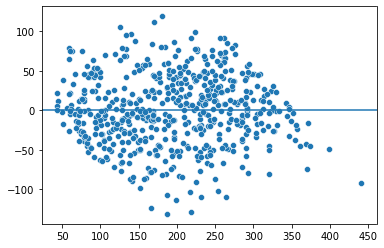

In [27]:
# Create a scatterplot of residuals against fitted values.

sns.scatterplot(x=fitted_values, y=residuals)
plt.axhline(0)
plt.show()

**Question:** Are the assumptions of independent observation and homoscedasticity met?


Yes, these assumptions are reasonably met. The scatterplot of residuals versus fitted values (page 15) shows no clear pattern or systematic structure, and the spread of residuals appears relatively constant across fitted values, indicating homoscedasticity and independence.

## **Considerations**

**What are some key takeaways that you learned during this lab?**

This lab demonstrated the complete workflow of performing simple linear regression, beginning with data exploration and cleaning, including identifying and handling missing values. It emphasized the importance of validating model assumptions such as linearity, normality, independence, and homoscedasticity both before and after model fitting. Additionally, the lab highlighted how to construct and interpret a regression model using the ordinary least squares (OLS) method, as well as how to evaluate model performance using statistical outputs and diagnostic plots.

**How would you present your findings from this lab to others?**

The findings would be presented using a combination of visualizations and concise statistical summaries. Key plots such as the regression line, residual distribution, and Q-Q plot would be used to illustrate the relationship and validate model assumptions. Additionally, the regression equation and key metrics (such as R-squared and coefficients) would be explained in simple terms to ensure clarity for both technical and non-technical audiences.

**What summary would you provide to stakeholders?**

The analysis indicates a strong positive relationship between radio advertising expenditure and sales. The regression model suggests that increased investment in radio promotions is associated with a significant increase in revenue. Given the strength of this relationship and the validity of model assumptions, stakeholders can consider allocating more resources to radio advertising as part of their marketing strategy to potentially maximize sales outcomes.

**References**

[Pandas.DataFrame.Any — Pandas 1.4.3 Documentation.](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.any.html)

[Pandas.DataFrame.Isna — Pandas 1.4.3 Documentation.](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isna.html)

[Pandas.Series.Sum — Pandas 1.4.3 Documentation.](https://pandas.pydata.org/docs/reference/api/pandas.Series.sum.html)

[Saragih, H.S. *Dummy Marketing and Sales Data*.](https://www.kaggle.com/datasets/harrimansaragih/dummy-advertising-and-sales-data)